Importing relevant libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Defining the function dy/dx=-2ycos(x), setting up h-values

In [2]:
# Function representing dy/dx = -2ycos(x)
def f(x, y):
    return -2 * y * np.cos(x)

# Creating array of hvalues to be tested
hvalues = np.arange(0,1,.05) + [.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

Using Euler's Method to solve the differential equation with varying values of h

Average y value at h=0.01: 1.9101617792186754
Average y value at h=0.05: 1.0178220080606892
Average y value at h=0.1: 0.5377260346485454
Average y value at h=0.15: 0.3197819117220568
Average y value at h=0.2: 0.20447268245849218
Average y value at h=0.25: 0.13579747480359125
Average y value at h=0.3: 0.09125639188830169
Average y value at h=0.35: 0.06084942690521079
Average y value at h=0.4: 0.039498449970983056
Average y value at h=0.45: 0.02501571846359043
Average y value at h=0.5: 0.015873015873015872
Average y value at h=0.55: 0.011934672322145672
Average y value at h=0.6: 0.013523407568370874
Average y value at h=0.65: 0.02096900039843341
Average y value at h=0.7: 0.030886059308825094
Average y value at h=0.75: 0.04591315686238471
Average y value at h=0.8: 0.07611538792962044
Average y value at h=0.85: 0.11852150043873337
Average y value at h=0.9: 0.2769182873506145
Average y value at h=0.95: 0.8205179594518478


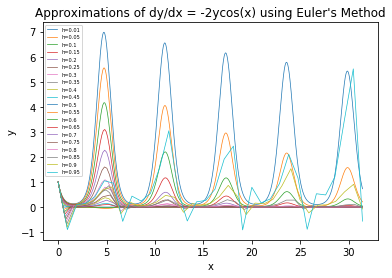

<Figure size 720x360 with 0 Axes>

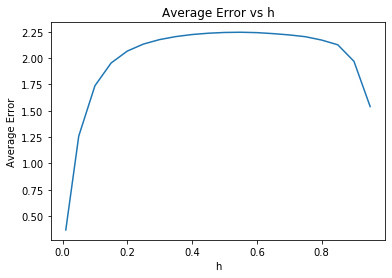

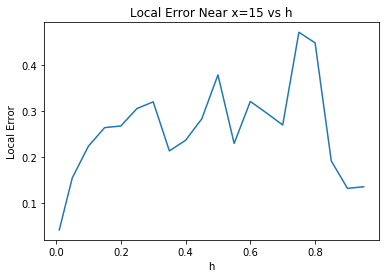

In [3]:
#Initializing array of average errors and errors near 15, for tracking
average_errors = []
fifteen_errors = []

for h in (hvalues):
    # Define parameters
    x_start, x_end = 0, 10 * np.pi
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Plot the approximations
    plt.plot(x_values, y_values, label= f"h={np.round(h,decimals=2)}", linewidth=.7)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("Approximations of dy/dx = -2ycos(x) using Euler's Method")
    
    # Print average y-values
    print(f"Average y value at h={np.round(h,decimals=2)}: {np.mean(y_values)}")
    
    # Error tracking
    point_error = np.abs(y_values - np.e**(-2*np.sin(x_values)))
    average_error = np.mean(point_error)
    average_errors.append(average_error)
    fifteen_index = np.argmin(np.abs(x_values-15))
    fifteen_errors.append(point_error[fifteen_index])

# Plot approximations on one graph
plt.legend(fontsize=5)
plt.figure(figsize=(10, 5))
plt.show()

# Plot average error against h values
plt.plot(hvalues, average_errors)
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title('Average Error vs h')
plt.show()

# Plot errors near x=15 against h values
plt.plot(hvalues, fifteen_errors)
plt.xlabel('h')
plt.ylabel('Local Error')
plt.title('Local Error Near x=15 vs h')
plt.show()

From the graph of the approximations, the plots with lower step sizes h have higher amplitudes; that is to say that they reach higher and lower values than the higher step sizes. This happens because the higher step sizes fail to capture the true shape of the graph and can't approximate the curve with as much accuracy. On the plot of average error vs h, it initially increases before levelling off and slightly decreasing. This initial increases is because the higher values of h will produce more error due to being lower fidelity and less accurate. However, for this specific differential equation, with high enough h values, the y values don't stray far from 0. So, the average error decreases and approaches the error for if you just used a horizontal line at 0. The local error near x=15 follows the same trend as the average error, initially decreasing then decreasing. This is for similar reasons, with the higher h values not varying from 0 very much.

# HOMEWORK 7s: ADDENDUM

To analyze the stability of Euler's method applied to dy/dx = -2y·cos(x), we first recognize 
that this ODE has the form dy/dx = λ(x)·y where λ(x) = -2cos(x) is a time-varying coefficient 
rather than a constant. The Euler update rule gives y_{i+1} = y_i(1 + h·λ(x_i)), so stability 
requires |1 + h·λ(x)| ≤ 1 at every step. Since cos(x) ∈ [-1, +1], our effective eigenvalue 
ranges over λ(x) ∈ [-2, +2], and we must check both extremes. When cos(x) = +1, the condition 
becomes |1 - 2h| ≤ 1, which is satisfied for h ≤ 1 — this is the stabilizing, damping region. 
However, when cos(x) = -1, the condition becomes |1 + 2h| ≤ 1, which requires h ≤ 0 and is 
therefore impossible for any positive step size. This means no fixed h > 0 achieves global 
stability; Euler's method is locally unstable near x = π, 3π, ... for every step size choice. 
In practice, the solution remains bounded because the exact solution y = e^{-2sin(x)} is itself 
bounded (since sin(x) ∈ [-1, 1], y stays within [e^{-2}, e^{2}]), and the destabilizing 
intervals are brief relative to the full period. Smaller values of h reduce error accumulation 
during these destabilizing phases, which is why h = 0.01 closely tracks the exact solution 
while larger values of h diverge — the step size does not eliminate local instability, but it 
controls how much that instability compounds over time.